In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/review_final_merged.csv')
display(df.head())

,Review_UID,Raw_Text,Cleaned_Text,Tokenized_Text,Aspect_맛,Aspect_서비스,Aspect_운영,Aspect_양
0,A1_S01_R001,로제반반 전화로 주문하여 방문으로 가져간 사람입니다! 너무 맛있게 잘먹었습니다!! ...,로제반반 전화로 주문하여 방문으로 가져간 사람입니다 너무 맛있게 잘먹었습니다 신선한...,"['전화', '주문', '하다', '방문', '으로', '가져가다', '사람', '...",0,0,0,0
1,A1_S01_R002,마라엽떡 맛있어요. 밥 비벼먹어도 굿!,마라엽떡 맛있어요 밥 비벼먹어도 굿,"['마라엽떡', '맛있다', '비비다', '먹다']",0,0,0,0
2,A1_S01_R003,너무맛있어요~~~~!!!!!! 직원분들친절하시공ㅎ 자주애용해요ㅎ,너무맛있어요 직원분들친절하시공 자주애용해요,"['너무', '맛있다', '직원', '친절하다', '시공', '자주', '애용']",0,0,0,0
3,A1_S01_R004,2층 홀도좋고 친절하시고 양도많고 너무좋네요~~,2층 홀도좋고 친절하시고 양도많고 너무좋네요,"['좋다', '친절하다', '양', '많다', '너무', '좋다']",0,0,0,0
4,A1_S01_R006,엽닭 존맛입니다,엽닭 존맛입니다,"['엽닭', '존맛', '이다']",0,0,0,0


In [ ]:
asp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/최종 감정분석.csv')
asp

,Review_UID,Final_Text,Aspect,Aspect_맛,Aspect_가격,Aspect_서비스,Aspect_위생
0,A1_S01_R001,로제반반 전화로 주문하여 방문으로 가져간 사람입니다 너무 맛있게 잘 먹었습니다 신선...,"맛, 서비스",1.0,NaN,+1,NaN
1,A1_S01_R002,마라엽떡 맛있어요. 밥 비벼먹어도 굿!,맛,1.0,NaN,NaN,NaN
2,A1_S01_R003,너무 맛있어요 직원분들 친절하시고 자주 애용해요,"맛, 서비스",1.0,NaN,+1,NaN
3,A1_S01_R004,2층 홀도 좋고 친절하시고 양도 많고 너무 좋네요,"가격, 서비스",NaN,1.0,+1,NaN
4,A1_S01_R006,엽기 닭발 존맛입니다,맛,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
4192,A4_S71_R075,스트레스받을 때는 매운 게 최고,맛,1.0,NaN,NaN,NaN
4193,A4_S71_R076,엽떡은 사랑입니다,맛,1.0,NaN,NaN,NaN
4194,A4_S71_R077,국물이 많고 다른 지점보다 덜 매워요 약간 아쉽네요,맛,-1.0,NaN,NaN,NaN
4195,A4_S71_R079,맵다 매워,맛,0.0,NaN,NaN,NaN


In [ ]:
df = df[['Review_UID', 'Tokenized_Text']]
display(df.head())

,Review_UID,Tokenized_Text
0,A1_S01_R001,"['전화', '주문', '하다', '방문', '으로', '가져가다', '사람', '..."
1,A1_S01_R002,"['마라엽떡', '맛있다', '비비다', '먹다']"
2,A1_S01_R003,"['너무', '맛있다', '직원', '친절하다', '시공', '자주', '애용']"
3,A1_S01_R004,"['좋다', '친절하다', '양', '많다', '너무', '좋다']"
4,A1_S01_R006,"['엽닭', '존맛', '이다']"


가격 언급
### **굵은 텍스트**
### Subtask:
Extract 'Review_UID's from `asp` where 'Aspect_위생' column is not NaN.


In [ ]:
review_uids_for_aspect_hygiene = asp[asp['Aspect_가격'].notna()]['Review_UID'].tolist()
print(f"Number of reviews with 'Aspect_가격': {len(review_uids_for_aspect_hygiene)}")
print(f"First 5 Review_UIDs: {review_uids_for_aspect_hygiene[:5]}")

Number of reviews with 'Aspect_가격': 661
First 5 Review_UIDs: ['A1_S01_R004', 'A1_S01_R007', 'A1_S01_R011', 'A1_S01_R055', 'A1_S01_R058']


In [ ]:
df_asp4 = df[df['Review_UID'].isin(review_uids_for_aspect_hygiene)][['Review_UID', 'Tokenized_Text']]
display(df_asp4.head())

,Review_UID,Tokenized_Text
3,A1_S01_R004,"['좋다', '친절하다', '양', '많다', '너무', '좋다']"
5,A1_S01_R007,"['착하다', '맛', '인분', '양', '적당하다', '맛있다']"
9,A1_S01_R011,"['너무', '마싯다', '엽떡', '가성', '비음', '같다']"
20,A1_S01_R055,"['대파', '양배추', '많이', '있다', '맛있다', '직원', '친절하다',..."
22,A1_S01_R058,"['엽떡', '어플', '매장', '방문', '3000원', '할인']"


In [ ]:
print(asp['Aspect_가격'].dtype)
print(asp['Aspect_가격'].unique()[:20])

float64
[nan  1.  0. -1.]


## 가격 부정적

### Subtask:
Extract 'Review_UID's from the `asp` DataFrame where the 'Aspect_위생' column has a value of -1.


In [ ]:
review_uids_neg_hygiene = asp[asp['Aspect_가격'] == -1 ]['Review_UID'].tolist()
print(f"'Aspect_가격' 부정적: {len(review_uids_neg_hygiene)}개")

'Aspect_가격' 부정적: 177개


In [ ]:
df_asp4_neg = df[df['Review_UID'].isin(review_uids_neg_hygiene)][['Review_UID', 'Tokenized_Text']]
df_asp4_neg

,Review_UID,Tokenized_Text
24,A1_S01_R061,"['둘이서', '먹기', '너무', '많다', '만원', '세트', '있다', '좋..."
71,A1_S03_R008,"['방문', '포장', '해오다', '에서', '먹다', '보다', '꾸다', '로..."
119,A1_S03_R081,"['양', '없다', '별로', '에요']"
175,A1_S05_R040,"['맛있다', '양', '적어지다', '같다']"
205,A1_S06_R020,"['사장', '친절하다', '포장', '할인', '혜택', '없다', '네이버', ..."
...,...,...
4158,A4_S70_R034,"['전화', '주문', '찾아가다', '3000원', '할인', '안해', '주니'..."
4159,A4_S70_R036,"['주방', '에서', '음식', '만들다', '주시', '사람', '마다', '양..."
4221,A4_S71_R022,"['맛있다', '한데', '이번', '뭔가', '재료', '너무', '적다', '먹..."
4228,A4_S71_R039,"['개인', '으로', '양배추', '많다', '좋다', '그런데', '평소', '..."


## 위생 긍정적

### Subtask:
Extract 'Review_UID's from the `asp` DataFrame where the 'Aspect_위생' column has a value of +1.

In [ ]:
review_uids_pos_hygiene = asp[asp['Aspect_가격'] == 1]['Review_UID'].tolist()
print(f"'Aspect_가격' 긍정적: {len(review_uids_pos_hygiene)}개")

'Aspect_가격' 긍정적: 437개


In [ ]:
df_asp4_pos = df[df['Review_UID'].isin(review_uids_pos_hygiene)][['Review_UID', 'Tokenized_Text']]
df_asp4_pos

,Review_UID,Tokenized_Text
3,A1_S01_R004,"['좋다', '친절하다', '양', '많다', '너무', '좋다']"
5,A1_S01_R007,"['착하다', '맛', '인분', '양', '적당하다', '맛있다']"
9,A1_S01_R011,"['너무', '마싯다', '엽떡', '가성', '비음', '같다']"
20,A1_S01_R055,"['대파', '양배추', '많이', '있다', '맛있다', '직원', '친절하다',..."
37,A1_S02_R016,"['양', '많다', '말다', '써다']"
...,...,...
4202,A4_S70_R103,"['맛있다', '양', '많다']"
4206,A4_S71_R004,"['인분', '포장', '해오다', '먹다', '양', '적당하다', '맛있다']"
4207,A4_S71_R005,"['양배추', '많이', '넣다', '감사하다', '직접', '매장', '에서', ..."
4216,A4_S71_R014,"['양', '푸다', '하고', '맛있다', '단점', '나오다', '너무', '오..."


#워드클라우드

## Prepare Review Text

### Subtask:
`df_asp4_neg` 데이터프레임의 'Tokenized_Text' 열에서 토큰화된 단어들을 추출하고, 이를 워드클라우드 생성을 위해 하나의 문자열로 결합합니다. 이때, 'Tokenized_Text' 컬럼이 문자열 형태의 리스트이므로 `ast.literal_eval`을 사용하여 실제 리스트로 변환하는 과정이 필요합니다.


In [ ]:
import ast

In [ ]:
negative_hygiene_text = ' '.join(df_asp4_neg['Tokenized_Text'].apply(lambda x: ' '.join(ast.literal_eval(x))))
print(f"Length of negative_hygiene_text: {len(negative_hygiene_text)}")
print(f"First 500 characters: {negative_hygiene_text[:500]}")

Length of negative_hygiene_text: 14531
First 500 characters: 둘이서 먹기 너무 많다 만원 세트 있다 좋다 남다 어쩔 방문 포장 해오다 에서 먹다 보다 꾸다 로우 밖에 들다 매장 전화 해보다 원래 크다 들다 하다 근데 쪼매난거 1조 각이랑 보통 크기 3조 각들어있었습니다 엽떡 살다 100 번은 먹다 보기 양 없다 별로 에요 맛있다 양 적어지다 같다 사장 친절하다 포장 할인 혜택 없다 네이버 페이 안되다 매장 깨끗하다 엽떡 떡볶이 오랜 먹다 싶다 포장 하다 가다 사장 친절하다 근데 양 적다 양 점차 줄어들다 이번 에는 너무 조금 들어서다 거의 감소 완전 실망하다 이상 문안 하다 양 전이 다르다 너무 적어지다 인엽떡 아니다 인엽떡임 떡볶이 시키다 양 적어지다 느끼다 떡볶이 맛 괜찮다 가게 입구 바닥 흥건 하고 방향 냄새 음식 냄새 약간 쓰레기 냄새 처럼 나다 테이블 먹다 남다 떡볶이 하나 치워지다 있다 갑자기 오다 치우다 휴지 주먹밥 만들다 비닐 장갑 그대로 놓다 가시 가게 테이블 만두 펼치다 놓다 오다 그거 으로 집다 들다 오늘 진짜 청결 상태 


In [ ]:
positive_hygiene_text = ' '.join(df_asp4_pos['Tokenized_Text'].apply(lambda x: ' '.join(ast.literal_eval(x))))
print(f"Length of positive_hygiene_text: {len(positive_hygiene_text)}")
print(f"First 500 characters: {positive_hygiene_text[:500]}")

Length of positive_hygiene_text: 22084
First 500 characters: 좋다 친절하다 양 많다 너무 좋다 착하다 맛 인분 양 적당하다 맛있다 너무 마싯다 엽떡 가성 비음 같다 대파 양배추 많이 있다 맛있다 직원 친절하다 감사하다 으로도 시키다 먹다 양 많다 말다 써다 양 많다 맛있다 엽떡 기적 으로 수혈 해주다 야하다 양 많다 맛있다 매장 테이블 있다 같다 보통 배달 주문 많다 기다리다 필요없다 바로 먹다 있다 대신 배달 주문 많다 음식 늦다 나오다 있다 하다 생각 보다 빨리 나오다 떡볶이 너무 맛있다 치즈 양 왜케 많다 행복하다 치즈 추다 하다 이렇게 항상 주시 가락 이용 하다 돌다 돌다 오랜 오리 지나다 먹다 엽떡 수혈 제대로 맛있다 자다 먹다 엽떡 가락 넘다 맛있다 기도 딱이다 양배추 까지 들다 넘다 맛있다 베이컨 추가 필수 이다 스페셜 세트 넷이서 배부르다 자다 먹다 엽떡 먹다 먹다 계속 있다 항상 신기하다 정도 푸다 양 이다 로제 착하다 맛 고소하다 투움바 파스타 비슷하다 먹다 있다 좋다 다음 에도 방문 하다 포장 할인 받다 먹음 처음 에는 오


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get update -qq
!apt-get install fonts-nanum -qq > /dev/null

# Find the path to a Nanum font
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# Add the font to matplotlib's font manager
fm.fontManager.addfont(fontpath)

# Rebuild matplotlib's font cache to recognize the new font
fm.findSystemFonts(fontpaths=None, fontext='ttf')

# Set the default font for matplotlib
plt.rc('font', family='NanumBarunGothic')

print(f"NanumBarunGothic font installed and set at: {fontpath}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
NanumBarunGothic font installed and set at: /usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf


##불용어

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

korean_stopwords = [
    '이', '그', '저', '것', '수', '등', '들', '및', '데', '개', '번', '나', '다', '의', '가', '은', '는', '도', '을', '를', '께', '에', '와', '과', '하다', '이다', '되다', '이다',
    '같다', '있다', '없다', '않다', '못하다', '되다', '이다', '아니다', '적다', '많다', '크다', '작다', '좋다', '나쁘다', '아깝다', '맛있다', '없다',
    '안', '못', '잘', '더', '좀', '가장', '제일', '꼭', '거의', '너무', '정말', '진짜', '아주', '몹시', '매우', '그냥', '그저', '그럼', '그리고', '그래서',
    '하지만', '그러나', '그런데', '또는', '만약', '혹은', '따라서', '그러므로', '때문에', '대하여', '관하여', '으로부터', '으로부터',
    '오다', '가다', '보다', '해주다', '해주시', '들다', '먹다', '마시다', '하다', '말하다', '주다', '시키다', '주문', '아니다', '받다', '받고다', '먹고다',
    '오늘', '내일', '모레', '어제', '작년', '올해', '내년', '새벽', '아침', '점심', '저녁', '밤', '요즘', '다시', '계속', '항상', '언제나', '빨리', '천천히',
    '어디', '어떻게', '왜', '무엇', '누구', '어느', '무슨', '몇', '어떤', '어느날', '어느새',
    '어떤', '분', '개', '점', '집', '곳', '것', '데', '번', '말', '글', '안녕', '그냥', '이렇다', '저렇다', '이렇고',
    '저렇고', '이런', '저런', '하다', '주다', '시키다', '아쉽다', '생각', '매우', '생기다', '방문', '진심', '조금', '정말', '이용', '이번', '재료', '다른', '생각보다', '다음',
    '맛', '에서', '이랑', '하고', '여기', '처음', '리뷰', '보기', '저희', '엽떡', '정도', '매장', '에도', '떡볶이', '지점',
    '그렇다', '인지', '이라', '1시간', '아예', '마다', '자다', '인데', '처럼', '추가', '양', '싶다', '까지', '이네', '여기다', '오스',
    '안되다', '드디어', '넘다', '되어다', '이나', '같다', '갈다', '리지', '아마도', '아마', '이고', '근데', '으로', '야하다', '건가', '다시다', '에는', '에요', '예요', '특히',
    '엄청', '되게', '부터', '비다', '먹기', '라고', '나오다', '인분', '맵다', '친절하다', '불친절하다', '테이블', '마라', '직원', '냄새', '사진', '알다', '전화', '꾸다', '바쁘다', '사진', '쓰다'
    '기다리다', '보이다', '만들다', '보고', '바로', '이렇게', '모르다', '시간', '푸다'
    ]
print("WordCloud and matplotlib.pyplot imported, and Korean stopwords defined.")

WordCloud and matplotlib.pyplot imported, and Korean stopwords defined.


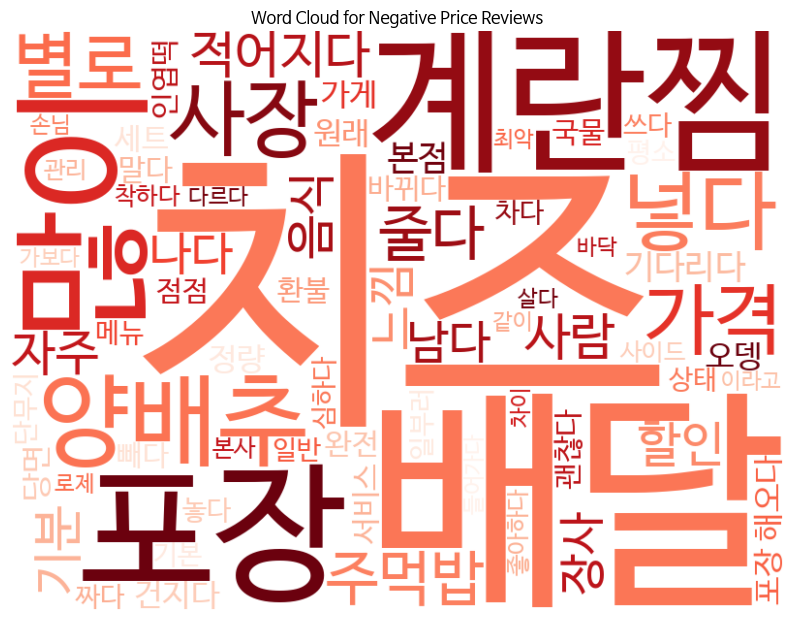

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc_neg = WordCloud(font_path=fontpath, background_color='white', width=800, height=600, stopwords=korean_stopwords, max_words=70, colormap='Reds').generate(negative_hygiene_text)
plt.figure(figsize=(10, 8))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Price Reviews')
plt.show()

**해석**

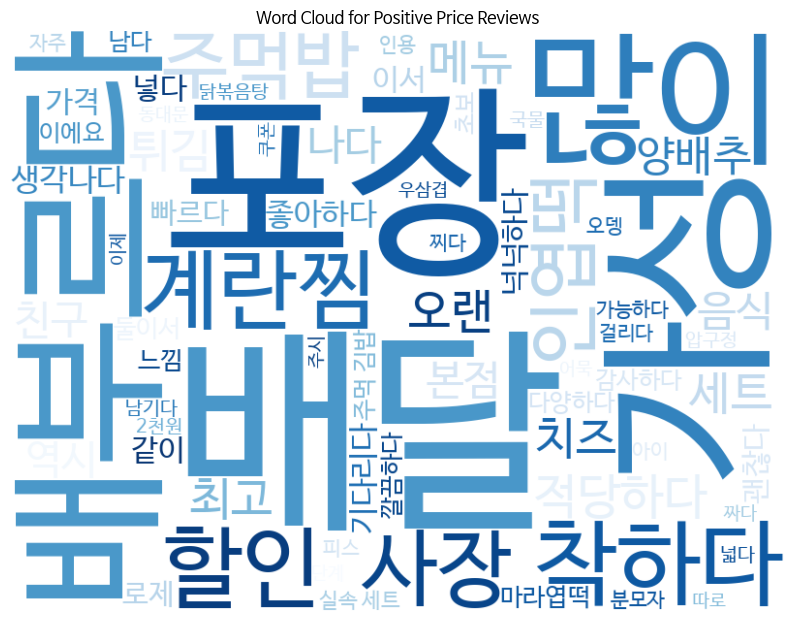

In [ ]:
wc_pos = WordCloud(font_path=fontpath, background_color='white', width=800, height=600, stopwords=korean_stopwords, max_words=70, colormap='Blues').generate(positive_hygiene_text)
plt.figure(figsize=(10, 8))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Price Reviews')
plt.show()

# **해석**

# 가격 Aspect에 대한 부정적 리뷰의 워드 클라우드 해석
## 1. 가격 자체에 대한 직접적 불만
### 대표 단어:

가격, 비다(비싸다 의미), 할인, 별로, 차다(비싸다는 의미 맥락 가능)

고객은 단순히 “비싸다”라고만 말하는 것이 아니라 다음과 같은 의미까지 포함:

- 가격이 전체 품질 대비 높다

- 기대 대비 만족도가 낮다(별로)

- 할인이 없거나, 할인해도 여전히 비싸다

즉, 단순 가격 수준이 아니라 지불 대비 가치(Value for Money)에 대한 실망이 크게 작용함.


## 2. 양·구성 대비 가격 불만
### 대표 단어:

양배, 양, 적어지다, 남다(남는 장사라는 뉘앙스), 세트, 사이드, 구성

고객이 가격을 비싸다고 느끼는 핵심 원인:

- 양이 적다 → 가격 대비 만족도 하락

- 예전보다 양이 줄어든 것 같다는 불신(적어지다, 점점)

즉, 고객은 **절대 가격보다 “가격 대비 양(Quantity)”**을 훨씬 중요하게 보고 있음.


## 3. 배달/포장 비용에 대한 거부감
### 대표 단어:

배달, 포장, 주먹밥(세트 구성 맥락), 오뎅, 장사, 손님, 사장

배달비 또는 포장 비용이 가격 불만을 강화:

- 배달비 포함 가격이 과하게 느껴짐

- 포장 옵션도 가격 대비 매력적이지 않음

- 일부 단어(사장, 장사)는 “너무 비싸게 받는다”라는 비난 맥락으로 해석 가능

즉, 고객은 배달비 + 음식 가격의 총합을 판단하며 “배달 프리미엄”에 불만 표출


## 4. 전반적 불만·감정 표현
### 대표 단어:

최악, 별로, 다르다, 짜다, 괜찮다(부정 속 긍정 뉘앙스), 상태, 건지다

가격 불만은 단순 수치 문제가 아니라 전반적 경험과 얽혀 나타남:

- “가격 대비 상태가 별로”

- “예전보다 다르다 → 가격 올렸는데 품질은 개선 없음”

- “건지다”는 가성비 맥락(이 가격이면 건진 게 없다)

음식 맛이나 품질 단어(짜다 등)도 나타나는데, 이는 가격이 높을수록 품질에 대한 기대치도 올라가기 때문임.

## 종합 결론

### 가격 관련 부정 리뷰의 핵심 패턴:

- 절대 가격이 비싸다.

- 양·구성 대비 가격이 납득되지 않는다.

- 배달·포장 비용의 체감 가격 상승이 큰 반감으로 연결된다.

- 가격이 오르면 품질 만족도 기준도 함께 높아지는데, 이를 충족하지 못한다.

즉, 고객은 단순히 “싼 것”을 원하는 것이 아니라:

“가격 대비 만족감이 합리적인가”
이 기준으로 강하게 평가하고 있다는 점이 드러남.

# 가격 Aspect에 대한 긍정적 리뷰의 워드 클라우드 해석

## 1. 가격 대비 “양이 많다”는 만족
### 대표 단어

많이, 양배추, 양, 넓다, 주먹밥, 계란찜, 푸짐, 음식

고객이 가격을 긍정적으로 평가할 때 가장 강하게 나타나는 요인은 양(Quantity):

- 양이 많아서 만족

- 구성품(계란찜, 주먹밥, 치즈, 양배추 등)이 넉넉함

- “푸짐하다”는 가격 대비 만족감을 매우 잘 드러냄

결론적으로, 가격 만족도 = 양의 만족도


## 2. 할인·혜택이 가격 긍정 인식에 핵심 기여
### 대표 단어

할인, 2천원, 실속, 세트, 가능하다

고객들은 할인 여부를 매우 민감하게 받아들이며, 할인 시:

- 가격 대비 만족도가 크게 상승

- “실속 있다”, “적당하다” 등 가성비 관점 표현 등장

즉, 가격 자체보다 “할인 후 가격”에 만족도가 생김.


## 3. 배달 가격 경험은 긍정적으로 연결될 때도 존재함
### 대표 단어

배달, 포장, 빠르다, 기다리다, 걸리다, 오랜

부정 리뷰에서는 배달비로 인해 불만이 늘어났지만,
긍정 리뷰에서는 배달 경험 자체가 만족 요인으로 연결됨:

- 배달이 빠르다 → 가격 대비 가치 상승

- 포장 상태가 좋다 → 지불한 가격이 아깝지 않다

즉, 배송·포장 품질이 가격 만족도에 직접 영향을 준다는 점이 드러남.


## 4. “착하다”는 가격이 합리적이라는 의미로 쓰임

워드클라우드 내 “착하다”는 대부분 다음 의미로 해석

가격에 대한 긍정 평가:

- 가격이 착하다 (저렴하거나 부담되지 않음)

- 구성 대비 합리적이다 (양·구성·사이드 포함)

- 할인·세트·양 등으로 가성비가 강화됨


## 5. 구성 요소·품질이 가격 대비 만족을 강화
### 대표 단어

치즈, 메뉴, 닭볶음탕, 국물, 세트, 우삼겹

즉, 가격이 합리적으로 느껴지는 이유는:

- 구성(세트 메뉴, 사이드)이 알차고

- 품질이 준수하며

- 선택 옵션이 다양하기 때문

이는 고객이 단순 금액보다 가격 대비 패키지 구성 전체를 평가한다는 점을 보여줌.


# 종합 결론

긍정적 가격 리뷰에서 고객은 다음 요인을 중심으로 “가성비가 좋다”고 판단:

- 양이 많고, 구성(세트·사이드)이 알차다.

- 할인 또는 혜택이 있어 실제 지불 가격이 낮아짐.

- 배달/포장 품질이 좋아 지불한 가격이 아깝지 않음.

- 사장님 친절도와 서비스가 심리적 만족도를 크게 높임.


즉, 가격 긍정 인식은 단순히 “저렴함”이 아니라:

# “가격 대비 경험 전체가 기대 이상이다”

라는 총체적 가치 평가에서 결정됨.